Global t.ratio range: ±6.0


<Figure size 2100x800 with 0 Axes>

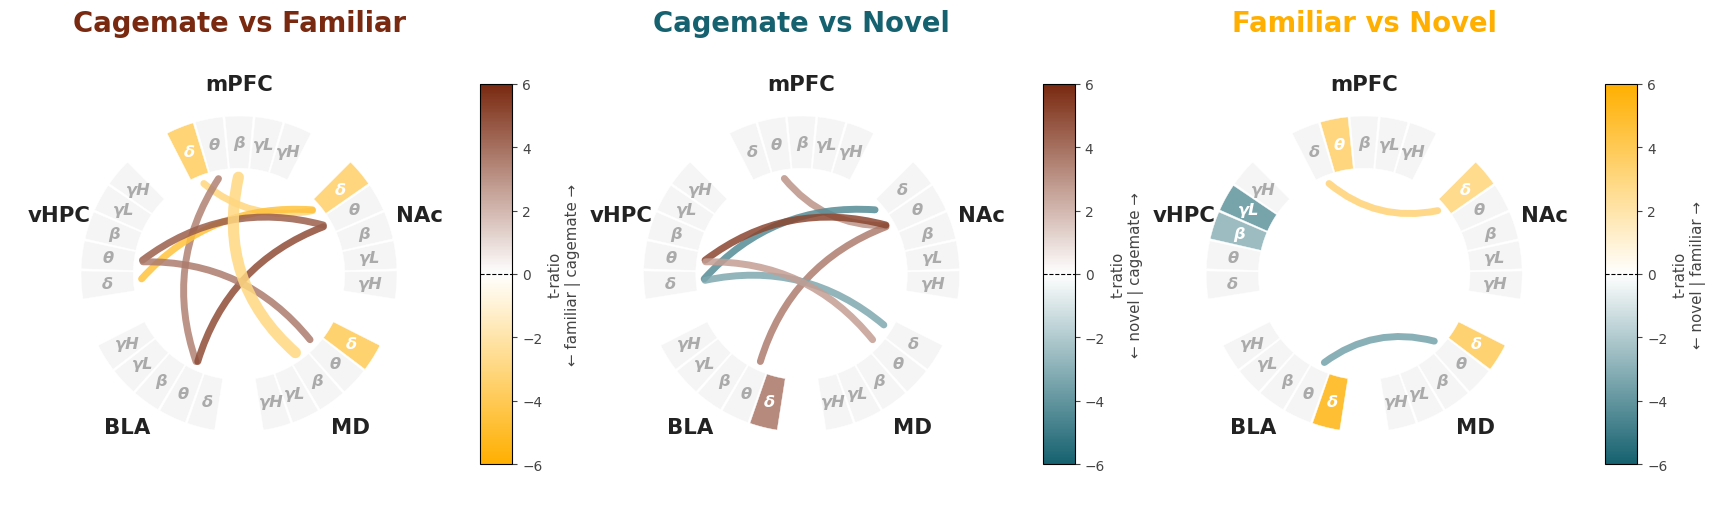

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/only_subjects/r_stuff/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_emm.csv")
power_contrasts     = pd.read_csv("pilot2/only_subjects/r_stuff/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)



# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    # ── Build contrast-specific sig filters ───────────────────────────────────
    sig_power_this = power_contrasts[
        power_contrasts["sig"].isin(REAL_SIG) &
        (power_contrasts["contrast"] == contrast)
    ].copy()

    sig_power_main_this = (
        sig_power_this[
            sig_power_this["plot_type"].str.contains("main_effect", na=False)
        ]
        .drop_duplicates(subset=["region"])
        [["region"]]
        .copy()
    )

    sig_coherence_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].notna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .rename(columns={"region": "pair"})
        .drop_duplicates(subset=["pair", "band"])
        [["pair", "band"]]
        .copy()
    )

    sig_coherence_main_this = (
        coherence_contrasts[
            coherence_contrasts["sig"].isin(REAL_SIG) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )

    # ── Local significance checker for power ──────────────────────────────────
    def is_sig_power_cell(region, band):
        band_sig = (
            (sig_power_this["region"] == region) &
            (sig_power_this["band"]   == band)
        ).any()
        main_sig = (
            (sig_power_main_this["region"] == region).any() and
            sig_power_this[sig_power_this["region"] == region].shape[0] > 0
        )
        return bool(band_sig or main_sig)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):

            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band)

            if is_sig:
                row = sig_power_this[
                    (sig_power_this["region"] == region) &
                    (sig_power_this["band"]   == band)
                ]
                if len(row) == 0:
                    # main effect fallback — use any sig row for this region
                    row = sig_power_this[sig_power_this["region"] == region]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # Region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Coherence chords — band-specific ─────────────────────────────────────
    plotted = set()

    for _, sig_row in sig_coherence_this.iterrows():
        pair = sig_row["pair"]
        band = sig_row["band"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        key = (tuple(sorted([r1, r2])), band)
        if key in plotted:
            continue
        plotted.add(key)

        emm_row = coherence_contrasts[
            (coherence_contrasts["region"]   == pair) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if len(emm_row) == 0:
            pair_rev = f"{r2}_{r1}"
            emm_row  = coherence_contrasts[
                (coherence_contrasts["region"]   == pair_rev) &
                (coherence_contrasts["band"]     == band) &
                (coherence_contrasts["contrast"] == contrast)
            ]

        t_val       = emm_row["t.ratio"].values[0] if len(emm_row) > 0 else 0.0
        chord_color = t_to_color(t_val, contrast=contrast, alpha=0.85)

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 5,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── Coherence chords — main effect (thick) ────────────────────────────────
    for _, main_row in sig_coherence_main_this.iterrows():
        pair = main_row["region"]
        t    = main_row["t.ratio"]

        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            continue

        chord_color = t_to_color(t, contrast=contrast, alpha=0.85)
        a1       = deg2rad(region_center_angles[r1])
        a2       = deg2rad(region_center_angles[r2])
        r_attach = 0.63
        x1, y1   = r_attach * np.cos(a1), r_attach * np.sin(a1)
        x2, y2   = r_attach * np.cos(a2), r_attach * np.sin(a2)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = "-",
                color           = chord_color,
                lw              = 8.0,
                connectionstyle = "arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")
fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

    
# ── RENDER — figure and axes FIRST, then plot loop ───────────────────────────

fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

plt.savefig("connectogram_contrasts.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [5]:
coherence_contrasts[(coherence_contrasts['region'] == 'mPFC_BLA') & (coherence_contrasts['band'] == 'Theta')]

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
21,mPFC_BLA,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,cagemate - familiar,Theta,5.418432,1.551083,3618.997924,3.493321,0.000483,0.005150,**
22,mPFC_BLA,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,cagemate - novel,Theta,2.563105,1.493346,3615.605501,1.716350,0.086184,0.266891,NaN
23,mPFC_BLA,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,familiar - novel,Theta,-2.855327,1.556668,3616.479978,-1.834256,0.066698,0.246270,NaN


Global t.ratio range: ±6.0


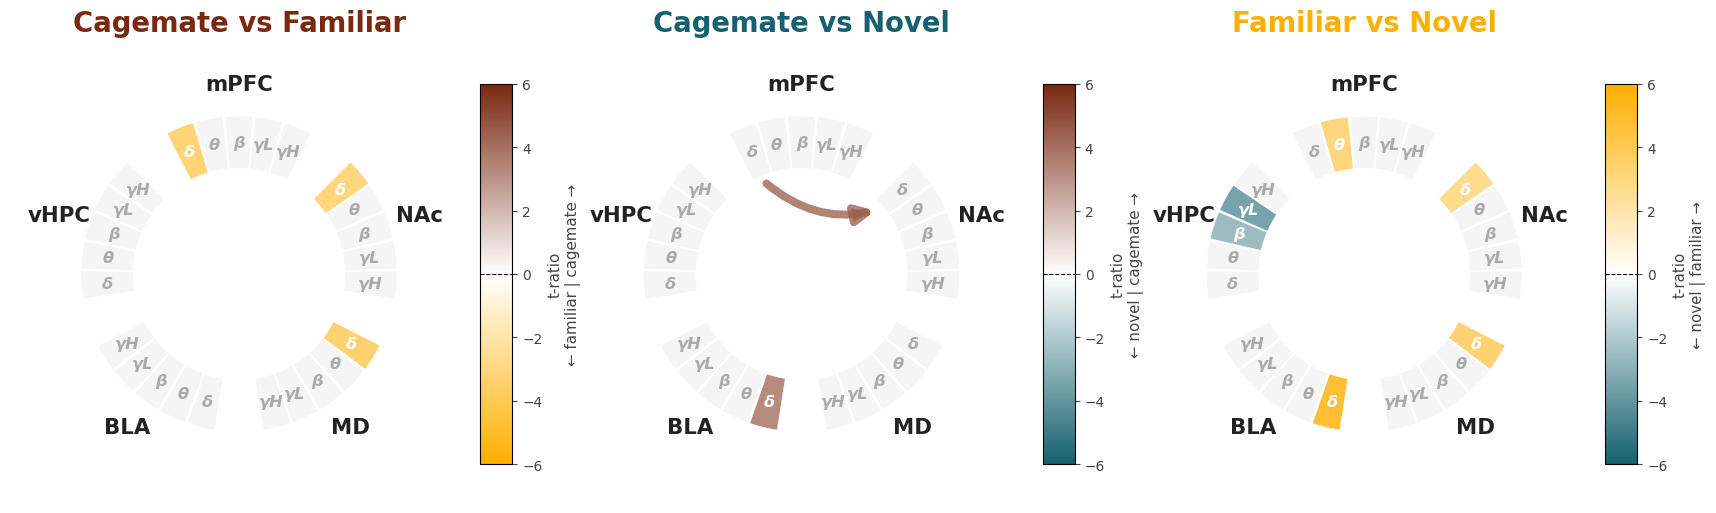

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/only_subjects/r_stuff/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_emm.csv")
granger_emm     = pd.read_csv("pilot2/only_subjects/r_stuff/granger_emm.csv")

power_contrasts     = pd.read_csv("pilot2/only_subjects/r_stuff/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_contrasts.csv")
granger_contrasts     = pd.read_csv("pilot2/only_subjects/r_stuff/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"] = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]       = granger_emm["region"].replace(name_fix)


# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                        coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba      = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3]   = alpha
    return tuple(rgba)

def parse_pair(pair_name):
    """For coherence — only valid if in coherence EMM."""
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    """For granger — parses A_to_B where both A, B are in regions."""
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    # fallback: try plain A_B format
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

region_span_deg = 55.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / len(bands)

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, band_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (band_idx + 0.5) * band_span_deg

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, band_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, band_idx))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── Power arcs ────────────────────────────────────────────────────────────
    for region in regions:
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]),
                    np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a),
                    label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS,
                    color=txt_col,
                    fontweight="bold",
                    fontstyle="italic",
                    zorder=4)

        # region label
        label_r = r_outer + 0.2
        label_a = deg2rad(region_center_angles[region])
        ax.text(label_r * np.cos(label_a),
                label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=8.5 * FS,
                fontweight="bold",
                color="#222222", zorder=4)

    # ── Granger directed arrows ───────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]

        if band not in bands:
            continue
        bi = bands.index(band)

        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast, alpha=0.4 + 0.5 * t_norm_mag)
        lw          = 2 + 5 * t_norm_mag   # 2–7 range
        arrow_size  = 12 + 18 * t_norm_mag  # 12–30 range

        x1, y1 = chord_endpoint(r1, bi, r=0.63)
        x2, y2 = chord_endpoint(r2, bi, r=0.63)

        ax.annotate("",
            xy      =(x2, y2), xycoords="data",
            xytext  =(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle      = f"-|>",
                color           = arrow_color,
                lw              = lw,
                mutation_scale  = arrow_size,
                connectionstyle = "arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER ────────────────────────────────────────────────────────────────────

fig      = plt.figure(figsize=(21, 8), facecolor="white")
outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

axes_main = []
axes_cbar = []

for i in range(3):
    inner_gs = GridSpecFromSubplotSpec(
        3, 2,
        subplot_spec  = outer_gs[i],
        width_ratios  = [1, 0.07],
        height_ratios = [0.15, 0.7, 0.15],
        wspace        = 0.05
    )
    axes_main.append(fig.add_subplot(inner_gs[:, 0]))
    axes_cbar.append(fig.add_subplot(inner_gs[1, 1]))

for ax, cbar_ax, contrast in zip(axes_main, axes_cbar, contrasts_to_plot):
    plot_granger_connectogram(
        ax             = ax,
        cbar_ax        = cbar_ax,
        contrast       = contrast,
        contrast_color = contrast_colors[contrast],
        contrast_label = contrast_labels[contrast]
    )

plt.savefig("connectogram_granger.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
granger_contrasts[granger_contrasts['sig'].isin(REAL_SIG)]

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
1,mPFC_to_NAc,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,cagemate - novel,Delta,12.723840,2.830000,4309.245729,4.496056,0.000007,0.000320,***
22,BLA_to_vHPC,value ~ band * agent + velocity_mouse1 + (1 | ...,main_effect,cagemate - novel,NaN,-7.238157,1.761147,2662.805295,-4.109910,0.000041,0.000917,***
23,BLA_to_vHPC,value ~ band * agent + velocity_mouse1 + (1 | ...,main_effect,familiar - novel,NaN,-5.973883,1.942302,2657.619885,-3.075672,0.002122,0.031825,*


In [18]:
power_contrasts[(power_contrasts['sig'] == '.')]

,region,model_formula,plot_type,contrast,band,estimate,SE,df,t.ratio,p.value,p.value.adjusted,sig
2,mPFC,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,familiar - novel,Delta,7.895093,3.039854,4626.509426,2.597195,0.009429,0.061524,.
33,MD,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,cagemate - familiar,Theta,7.716536,3.089192,4653.039032,2.497914,0.012527,0.072271,.
48,BLA,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,cagemate - familiar,Theta,7.449668,2.884817,4474.704709,2.582371,0.009844,0.061524,.
74,vHPC,value ~ band * agent + velocity_mouse1 + (1 | ...,interaction,familiar - novel,High gamma,-13.889970,5.901010,3576.079869,-2.353829,0.018635,0.099830,.


Global t.ratio range: ±6.0


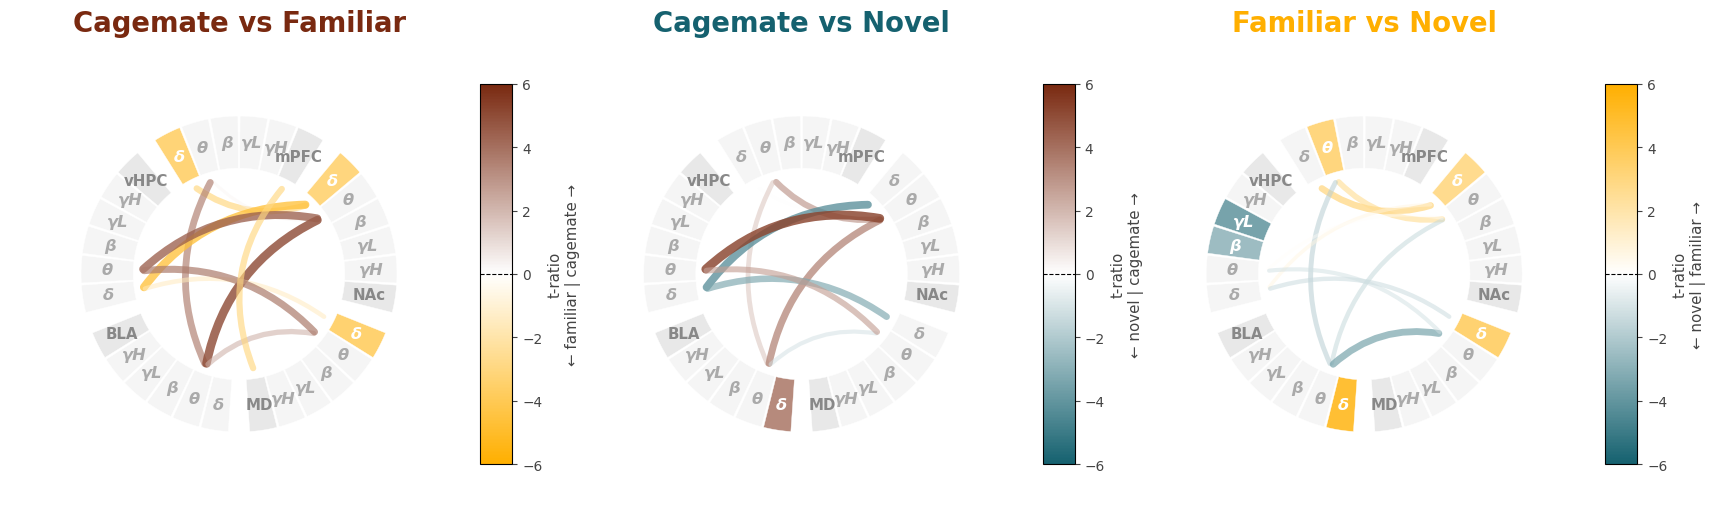

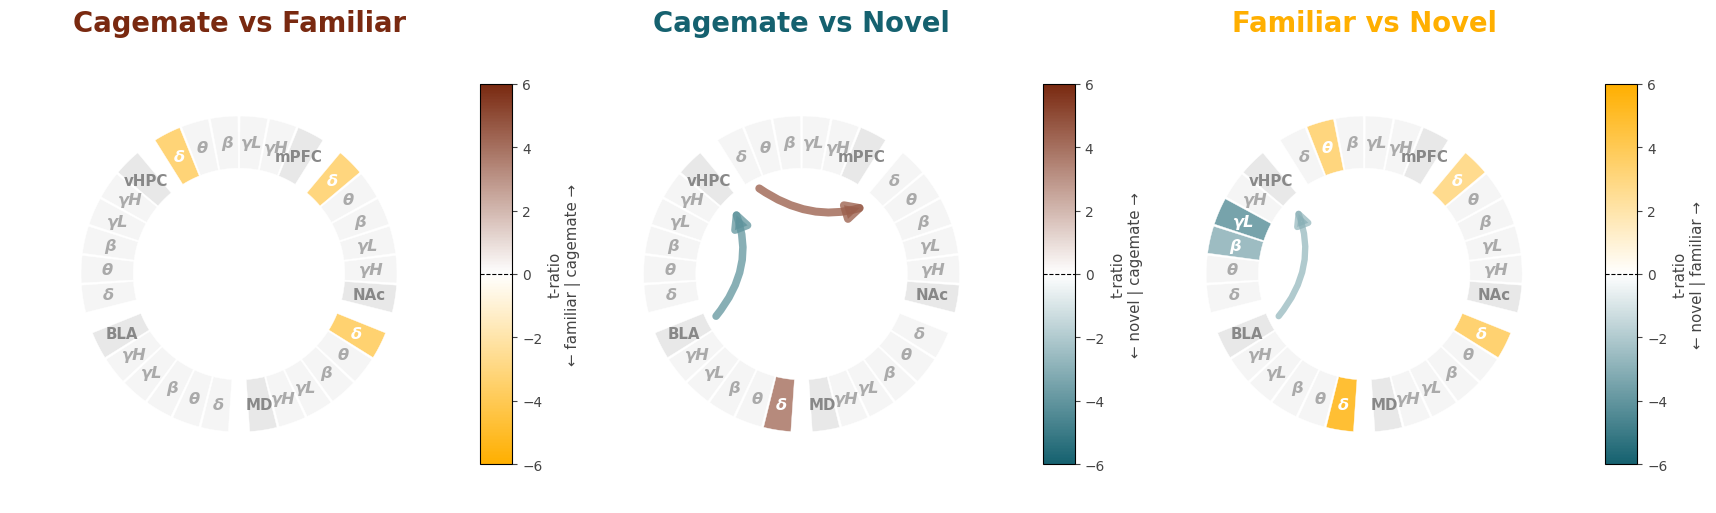

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.cm import ScalarMappable
import pandas as pd

# ── COLORS ────────────────────────────────────────────────────────────────────

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

# ── LAYOUT ────────────────────────────────────────────────────────────────────

regions    = ["mPFC", "NAc", "MD", "BLA", "vHPC"]
bands      = ["Delta", "Theta", "Beta", "Low gamma", "High gamma"]
band_greek = ["δ", "θ", "β", "γL", "γH"]
FS         = 1.8

contrasts_to_plot = [
    "cagemate - familiar",
    "cagemate - novel",
    "familiar - novel"
]

contrast_labels = {
    "cagemate - familiar": "Cagemate vs Familiar",
    "cagemate - novel":    "Cagemate vs Novel",
    "familiar - novel":    "Familiar vs Novel"
}

contrast_colors = {
    "cagemate - familiar": "#792910",
    "cagemate - novel":    "#15616F",
    "familiar - novel":    "#FFAF00"
}

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

power_emm           = pd.read_csv("pilot2/only_subjects/r_stuff/power_emm.csv")
coherence_emm       = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_emm.csv")
granger_emm         = pd.read_csv("pilot2/only_subjects/r_stuff/granger_emm.csv")
power_contrasts     = pd.read_csv("pilot2/only_subjects/r_stuff/power_contrasts.csv")
coherence_contrasts = pd.read_csv("pilot2/only_subjects/r_stuff/coherence_contrasts.csv")
granger_contrasts   = pd.read_csv("pilot2/only_subjects/r_stuff/granger_contrasts.csv")

# ── FIX CAPITALIZATION ────────────────────────────────────────────────────────

name_fix = {"mPFC_Nac": "mPFC_NAc"}
coherence_emm["region"]       = coherence_emm["region"].replace(name_fix)
coherence_contrasts["region"] = coherence_contrasts["region"].replace(name_fix)
granger_contrasts["region"]   = granger_contrasts["region"].replace(name_fix)
granger_emm["region"]         = granger_emm["region"].replace(name_fix)

# ── SIGNIFICANT FILTER ────────────────────────────────────────────────────────

REAL_SIG = ["*", "**", "***"]

def is_real_sig(series):
    return series.notna() & series.isin(REAL_SIG)

sig_power = power_contrasts[is_real_sig(power_contrasts["sig"])].copy()

sig_power_main = (
    power_contrasts[
        is_real_sig(power_contrasts["sig"]) &
        power_contrasts["plot_type"].str.contains("main_effect", na=False)
    ]
    .drop_duplicates(subset=["region"])
    [["region"]]
    .copy()
)

sig_coherence_pairs = (
    coherence_contrasts[
        is_real_sig(coherence_contrasts["sig"]) &
        coherence_contrasts["band"].notna()
    ]
    .rename(columns={"region": "pair"})
    .drop_duplicates(subset=["pair", "band"])
    [["pair", "band"]]
    .copy()
)

sig_granger_pairs = (
    granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].notna()
    ]
    .drop_duplicates(subset=["region", "band", "contrast"])
    [["region", "band", "contrast", "t.ratio"]]
    .copy()
)

valid_coherence_pairs = coherence_emm["region"].unique().tolist()

# ── GLOBAL T.RATIO RANGE ──────────────────────────────────────────────────────

all_t     = pd.concat([power_contrasts["t.ratio"].dropna(),
                       coherence_contrasts["t.ratio"].dropna()])
t_abs_max = np.ceil(all_t.abs().max())
norm      = Normalize(vmin=-t_abs_max, vmax=t_abs_max)

print(f"Global t.ratio range: ±{t_abs_max}")

# ── CONTRAST COLORMAPS ────────────────────────────────────────────────────────

def make_contrast_cmap(contrast_str):
    agents    = [a.strip() for a in contrast_str.split(" - ")]
    color_pos = mcolors.to_rgb(agent_colors[agents[0]])
    color_neg = mcolors.to_rgb(agent_colors[agents[1]])
    white     = (1.0, 1.0, 1.0)
    return LinearSegmentedColormap.from_list(
        f"cmap_{contrast_str}",
        [color_neg, white, color_pos]
    )

contrast_cmaps = {c: make_contrast_cmap(c) for c in contrasts_to_plot}

def t_to_color(t_ratio, contrast, alpha=1.0):
    rgba    = list(contrast_cmaps[contrast](norm(t_ratio)))
    rgba[3] = alpha
    return tuple(rgba)

# ── GEOMETRY ──────────────────────────────────────────────────────────────────

n_blocks        = len(bands) + 1                                          # 5 bands + 1 region block
region_span_deg = 65.0
gap_deg         = (360.0 - region_span_deg * len(regions)) / len(regions)
band_span_deg   = region_span_deg / n_blocks

region_center_angles = {}
start = 90.0
for i, r in enumerate(regions):
    region_center_angles[r] = start - i * (region_span_deg + gap_deg)

def band_center_deg(region, block_idx):
    rc    = region_center_angles[region]
    start = rc + region_span_deg / 2.0
    return start - (block_idx + 0.5) * band_span_deg

def region_block_center_deg(region):
    return band_center_deg(region, len(bands))   # last block

def deg2rad(d):
    return np.pi * d / 180.0

def arc_polygon(center_deg, half_deg, r_inner, r_outer, n=60):
    a0     = deg2rad(center_deg - half_deg)
    a1     = deg2rad(center_deg + half_deg)
    angles = np.linspace(a0, a1, n)
    xs     = np.concatenate([r_outer * np.cos(angles),
                              r_inner * np.cos(angles[::-1])])
    ys     = np.concatenate([r_outer * np.sin(angles),
                              r_inner * np.sin(angles[::-1])])
    return xs, ys

def chord_endpoint(region, block_idx, r=0.62):
    angle = deg2rad(band_center_deg(region, block_idx))
    return r * np.cos(angle), r * np.sin(angle)

def region_block_endpoint(region, r=0.62):
    angle = deg2rad(region_block_center_deg(region))
    return r * np.cos(angle), r * np.sin(angle)

def parse_pair(pair_name):
    if pair_name not in valid_coherence_pairs:
        return None, None
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def parse_any_pair(pair_name):
    if "_to_" in pair_name:
        parts = pair_name.split("_to_")
        if len(parts) == 2 and parts[0] in regions and parts[1] in regions:
            return parts[0], parts[1]
    for r1 in regions:
        if pair_name.startswith(r1 + "_"):
            r2 = pair_name[len(r1) + 1:]
            if r2 in regions:
                return r1, r2
    return None, None

def is_sig_power_cell(region, band, contrast):
    band_sig = (
        (sig_power["region"]   == region) &
        (sig_power["band"]     == band) &
        (sig_power["contrast"] == contrast)
    ).any()
    main_sig = (
        (sig_power_main["region"] == region).any() and
        (
            power_contrasts[
                (power_contrasts["region"]   == region) &
                (power_contrasts["contrast"] == contrast) &
                is_real_sig(power_contrasts["sig"])
            ].shape[0] > 0
        )
    )
    return bool(band_sig or main_sig)

# ── COHERENCE PLOT FUNCTION ───────────────────────────────────────────────────

def plot_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level coherence chords ───────────────────────────────────────────
    plotted = set()
    for _, row in sig_coherence_pairs.iterrows():
        pair = row["pair"]
        band = row["band"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        key = (pair, band)
        if key in plotted:
            continue
        plotted.add(key)

        coh_row = coherence_contrasts[
            (coherence_contrasts["region"].isin([pair, f"{r2}_{r1}"])) &
            (coherence_contrasts["band"]     == band) &
            (coherence_contrasts["contrast"] == contrast)
        ]
        if coh_row.empty:
            continue
        t_coh       = coh_row["t.ratio"].values[0]
        t_norm_mag  = min(abs(t_coh) / t_abs_max, 1.0)
        chord_color = t_to_color(t_coh, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=1
        )

    # ── main effect coherence chords (region block → region block) ────────────
    sig_coh_main = (
        coherence_contrasts[
            is_real_sig(coherence_contrasts["sig"]) &
            coherence_contrasts["band"].isna() &
            (coherence_contrasts["contrast"] == contrast)
        ]
        .drop_duplicates(subset=["region"])
        [["region", "t.ratio"]]
        .copy()
    )
    for _, mrow in sig_coh_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_pair(pair)
        if r1 is None or r2 is None:
            r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue
        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        chord_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-", color=chord_color,
                lw=2 + 5 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=1
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── GRANGER PLOT FUNCTION ─────────────────────────────────────────────────────

def plot_granger_connectogram(ax, cbar_ax, contrast, contrast_color, contrast_label):

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_title(contrast_label,
                 color=contrast_color, fontsize=11 * FS,
                 fontweight="bold", pad=10)

    r_inner = 0.67
    r_outer = 1.00
    half    = band_span_deg / 2.0 - 0.4

    # ── band blocks + region block ────────────────────────────────────────────
    for region in regions:

        # band blocks (0–4)
        for bi, (band, greek) in enumerate(zip(bands, band_greek)):
            center = band_center_deg(region, bi)
            is_sig = is_sig_power_cell(region, band, contrast)

            if is_sig:
                row = power_contrasts[
                    (power_contrasts["region"]   == region) &
                    (power_contrasts["band"]     == band) &
                    (power_contrasts["contrast"] == contrast)
                ]
                if len(row) == 0:
                    row = power_contrasts[
                        (power_contrasts["region"]   == region) &
                        (power_contrasts["contrast"] == contrast) &
                        is_real_sig(power_contrasts["sig"])
                    ]
                t_val = row["t.ratio"].values[0] if len(row) > 0 else 0.0
                color = t_to_color(t_val, contrast=contrast, alpha=0.9)
            else:
                color = (0.85, 0.85, 0.85, 0.25)

            xs, ys = arc_polygon(center, half, r_inner, r_outer)
            ax.fill(xs, ys, color=color, linewidth=0, zorder=2)
            ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                    color="white", lw=0.3, zorder=3)

            label_r = (r_inner + r_outer) / 2.0
            label_a = deg2rad(center)
            txt_col = "white" if is_sig else "#AAAAAA"
            ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                    greek,
                    ha="center", va="center",
                    fontsize=6.5 * FS, color=txt_col,
                    fontweight="bold", fontstyle="italic", zorder=4)

        # region block (index 5) — colored by main effect power
        center   = region_block_center_deg(region)
        main_row = power_contrasts[
            (power_contrasts["region"]   == region) &
            (power_contrasts["contrast"] == contrast) &
            power_contrasts["band"].isna() &
            is_real_sig(power_contrasts["sig"])
        ]
        if not main_row.empty:
            t_val       = main_row["t.ratio"].values[0]
            block_color = t_to_color(t_val, contrast=contrast, alpha=0.95)
            txt_col     = "white"
        else:
            block_color = (0.75, 0.75, 0.75, 0.35)
            txt_col     = "#888888"

        xs, ys = arc_polygon(center, half, r_inner, r_outer)
        ax.fill(xs, ys, color=block_color, linewidth=0, zorder=2)
        ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                color="white", lw=0.3, zorder=3)

        label_r = (r_inner + r_outer) / 2.0
        label_a = deg2rad(center)
        ax.text(label_r * np.cos(label_a), label_r * np.sin(label_a),
                region,
                ha="center", va="center",
                fontsize=6.0 * FS, color=txt_col,
                fontweight="bold", zorder=4)

    # ── band-level granger arrows ─────────────────────────────────────────────
    gran_contrast = sig_granger_pairs[
        sig_granger_pairs["contrast"] == contrast
    ].copy()

    for _, row in gran_contrast.iterrows():
        pair = row["region"]
        band = row["band"]
        t    = row["t.ratio"]
        if band not in bands:
            continue
        bi     = bands.index(band)
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = chord_endpoint(r1, bi)
        x2, y2 = chord_endpoint(r2, bi)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.25"
            ),
            zorder=3
        )

    # ── main effect granger arrows (region block → region block) ─────────────
    gran_main = granger_contrasts[
        is_real_sig(granger_contrasts["sig"]) &
        granger_contrasts["band"].isna() &
        (granger_contrasts["contrast"] == contrast)
    ].copy()

    for _, mrow in gran_main.iterrows():
        pair   = mrow["region"]
        t      = mrow["t.ratio"]
        r1, r2 = parse_any_pair(pair)
        if r1 is None or r2 is None:
            continue

        t_norm_mag  = min(abs(t) / t_abs_max, 1.0)
        arrow_color = t_to_color(t, contrast=contrast,
                                 alpha=0.4 + 0.5 * t_norm_mag)
        x1, y1 = region_block_endpoint(r1)
        x2, y2 = region_block_endpoint(r2)

        ax.annotate("",
            xy=(x2, y2), xycoords="data",
            xytext=(x1, y1), textcoords="data",
            arrowprops=dict(
                arrowstyle="-|>",
                color=arrow_color,
                lw=2 + 5 * t_norm_mag,
                mutation_scale=12 + 18 * t_norm_mag,
                connectionstyle="arc3,rad=0.3"
            ),
            zorder=3
        )

    # ── colorbar ──────────────────────────────────────────────────────────────
    sm = ScalarMappable(cmap=contrast_cmaps[contrast], norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cbar_ax, orientation="vertical")
    cb.set_label(
        f"t-ratio\n← {contrast.split(' - ')[1]} | {contrast.split(' - ')[0]} →",
        fontsize=6 * FS, color="#444444"
    )
    cb.ax.tick_params(labelsize=5.5 * FS, colors="#444444")
    cb.ax.axhline(y=0, color="black", lw=0.8, linestyle="--")


# ── RENDER BOTH FIGURES ───────────────────────────────────────────────────────

for plot_fn, fname, title in [
    (plot_connectogram,         "connectogram_coherence.png", "Coherence"),
    (plot_granger_connectogram, "connectogram_granger.png",   "Granger"),
]:
    fig      = plt.figure(figsize=(21, 8), facecolor="white")
    outer_gs = GridSpec(1, 3, wspace=0.12, figure=fig)

    for i, contrast in enumerate(contrasts_to_plot):
        inner_gs = GridSpecFromSubplotSpec(
            3, 2,
            subplot_spec  = outer_gs[i],
            width_ratios  = [1, 0.07],
            height_ratios = [0.15, 0.7, 0.15],
            wspace        = 0.05
        )
        ax      = fig.add_subplot(inner_gs[:, 0])
        cbar_ax = fig.add_subplot(inner_gs[1, 1])
        plot_fn(
            ax             = ax,
            cbar_ax        = cbar_ax,
            contrast       = contrast,
            contrast_color = contrast_colors[contrast],
            contrast_label = contrast_labels[contrast]
        )

    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()